<a href="https://colab.research.google.com/github/TanmayYenge/credit-default-prediction/blob/main/notebooks/credit_default_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
import pandas as pd

file_path = "/content/drive/MyDrive/BA889_ResearchProposal/loans_clean.parquet"
df = pd.read_parquet(file_path)
print("Loaded:", df.shape)
df.head()

Loaded: (943345, 39)


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,num_tl_90g_dpd_24m,pct_tl_nvr_dlq,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,FEDFUNDS,unem_rate,inf,gdppercap,target
0,11875,36 months,0.1531,413.459990,C,C2,2 years,MORTGAGE,49800.0,Source Verified,...,0,90.0,0,0,227318,0.14,0.065,0.0,6582.5728,0
1,11500,36 months,0.1849,418.590000,D,D2,1 year,OWN,34000.0,Not Verified,...,0,100.0,0,0,12200,0.14,0.065,0.0,6582.5728,0
2,2300,36 months,0.0890,73.040001,A,A5,10+ years,RENT,34000.0,Verified,...,0,85.0,0,0,28474,0.14,0.065,0.0,6582.5728,0
3,19600,36 months,0.1409,670.739990,B,B5,7 years,RENT,50000.0,Not Verified,...,0,100.0,0,0,12019,0.07,0.070,0.0,6719.4287,1
4,3900,36 months,0.1311,131.620000,B,B4,7 years,RENT,29000.0,Source Verified,...,0,100.0,0,0,6800,0.10,0.070,0.0,6684.6826,1


In [21]:
# Re-apply outlier handling (same as local)
before = len(df)
df = df[df['dti'] <= 100].copy()
inc_cap = df['annual_inc'].quantile(0.99)
df['annual_inc'] = df['annual_inc'].clip(upper=inc_cap)
print(f"Rows after DTI filter: {len(df):,} (removed {before-len(df)})")
print(f"Income capped at: ${inc_cap:,.0f}")

Rows after DTI filter: 942,911 (removed 434)
Income capped at: $260,000


In [22]:
import numpy as np

numeric_df = df.select_dtypes(include=[np.number])
target_corr = numeric_df.corr()['target'].drop('target').sort_values(key=abs, ascending=False)

print("Features most correlated with default (by absolute strength):\n")
print(target_corr.head(20))

Features most correlated with default (by absolute strength):

int_rate                0.248496
FEDFUNDS               -0.140066
dti                     0.109383
unem_rate               0.089583
acc_open_past_24mths    0.084181
tot_hi_cred_lim        -0.079350
avg_cur_bal            -0.077521
revol_util              0.076208
num_actv_rev_tl         0.073771
tot_cur_bal            -0.071430
mort_acc               -0.068821
inq_last_6mths          0.066262
annual_inc             -0.065384
loan_amnt               0.064255
installment             0.047570
mo_sin_old_rev_tl_op   -0.044766
num_actv_bc_tl          0.043053
inf                     0.038600
gdppercap               0.031553
open_acc                0.024124
Name: target, dtype: float64


In [23]:
# Inventory the categorical/text columns that need encoding before modeling
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns needing treatment:\n")
for c in cat_cols:
    n_unique = df[c].nunique()
    print(f"  {c:<22} {n_unique} unique values")

print("\nAlso to engineer:")
print("  earliest_cr_line -> convert to credit history length in years")
print("  emp_length       -> has ~55K missing, needs handling")

Categorical columns needing treatment:

  term                   2 unique values
  grade                  7 unique values
  sub_grade              35 unique values
  emp_length             11 unique values
  home_ownership         6 unique values
  verification_status    3 unique values
  purpose                13 unique values
  addr_state             51 unique values
  earliest_cr_line       740 unique values
  application_type       5 unique values

Also to engineer:
  earliest_cr_line -> convert to credit history length in years
  emp_length       -> has ~55K missing, needs handling


In [24]:
import numpy as np

df_model = df.copy()

# --- Normalize application_type (fix capitalization duplicates + stray value) ---
df_model['application_type'] = df_model['application_type'].str.upper().str.strip()
# Collapse the joint variants into one, individual into one
df_model['application_type'] = df_model['application_type'].replace({
    'JOINT APP': 'JOINT',
    'DIRECT_PAY': 'INDIVIDUAL'  # stray disbursement value -> treat as individual (majority)
})
print("Cleaned application_type values:")
print(df_model['application_type'].value_counts())

# --- 1. Drop grade (keeping sub_grade) ---
df_model = df_model.drop(columns=['grade'])

# --- 2. Ordinal encode sub_grade (A1=0 ... G5=34) ---
subgrades = sorted(df_model['sub_grade'].unique())  # A1, A2... G5 sort correctly
subgrade_map = {sg: i for i, sg in enumerate(subgrades)}
df_model['sub_grade'] = df_model['sub_grade'].map(subgrade_map)

# --- 3. Ordinal encode emp_length (missing -> -1 as its own category) ---
emp_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
    '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9, '10+ years': 10
}
df_model['emp_length'] = df_model['emp_length'].map(emp_map).fillna(-1)

# --- 4. Engineer credit history length (years) from earliest_cr_line ---
# Format is two-digit year like "Jul-98", so use %y (lowercase)
df_model['earliest_cr_line'] = pd.to_datetime(
    df['earliest_cr_line'], format='%b-%y', errors='coerce'
)
# Fix century problem: two-digit years past ~2020 are actually 1900s
# (e.g. "78" parsed as 2078 should be 1978)
mask = df_model['earliest_cr_line'] > pd.Timestamp('2020-01-01')
df_model.loc[mask, 'earliest_cr_line'] -= pd.DateOffset(years=100)

ref_date = pd.Timestamp('2019-01-01')
df_model['credit_history_years'] = (ref_date - df_model['earliest_cr_line']).dt.days / 365.25
df_model = df_model.drop(columns=['earliest_cr_line'])

# --- 5. Handle the tiny remaining missing values ---
df_model['revol_util'] = df_model['revol_util'].fillna(df_model['revol_util'].median())
df_model['mo_sin_old_rev_tl_op'] = df_model['mo_sin_old_rev_tl_op'].fillna(df_model['mo_sin_old_rev_tl_op'].median())
df_model['credit_history_years'] = df_model['credit_history_years'].fillna(df_model['credit_history_years'].median())

# --- 6. One-hot encode nominal categoricals ---
onehot_cols = ['term', 'home_ownership', 'verification_status', 'application_type', 'purpose', 'addr_state']
df_model = pd.get_dummies(df_model, columns=onehot_cols, drop_first=True)

# --- Check the result ---
print("Final shape:", df_model.shape)
print("Any remaining missing values:", df_model.isnull().sum().sum())
print("Any non-numeric columns left:", df_model.select_dtypes(include=['object']).columns.tolist())
print("\ncredit_history_years summary:")
print(df_model['credit_history_years'].describe())

Cleaned application_type values:
application_type
INDIVIDUAL    924900
JOINT          18011
Name: count, dtype: int64
Final shape: (942911, 103)
Any remaining missing values: 0
Any non-numeric columns left: []

credit_history_years summary:
count    942911.000000
mean         19.739608
std           7.630820
min           2.250513
25%          14.502396
50%          18.417522
75%          23.671458
max          84.752909
Name: credit_history_years, dtype: float64


MODELLING

In [25]:
from sklearn.model_selection import train_test_split

# Separate features (X) from target (y)
X = df_model.drop(columns=['target'])
y = df_model['target']

# Split 80/20, stratified to preserve the 18.9% default rate in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Test set:     {X_test.shape[0]:,} rows")
print(f"\nDefault rate — train: {y_train.mean()*100:.1f}%  |  test: {y_test.mean()*100:.1f}%")
print(f"Number of features: {X_train.shape[1]}")

Training set: 754,328 rows
Test set:     188,583 rows

Default rate — train: 18.9%  |  test: 18.9%
Number of features: 102


In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# Scale features — required for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled = scaler.transform(X_test)         # apply same scaling to test

# Train Logistic Regression with class weighting to handle imbalance
logreg = LogisticRegression(
    class_weight='balanced',   # <-- directly addresses the imbalance
    max_iter=1000,
    random_state=42
)
logreg.fit(X_train_scaled, y_train)

# Predict on the held-out test set
y_pred = logreg.predict(X_test_scaled)
y_proba = logreg.predict_proba(X_test_scaled)[:, 1]   # probability of default

# Evaluate
print("=== Logistic Regression (baseline) ===\n")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}\n")
print("Classification report:")
print(classification_report(y_test, y_pred, target_names=['Paid', 'Default']))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

=== Logistic Regression (baseline) ===

ROC-AUC: 0.7409

Classification report:
              precision    recall  f1-score   support

        Paid       0.90      0.69      0.78    152997
     Default       0.33      0.66      0.44     35586

    accuracy                           0.68    188583
   macro avg       0.61      0.68      0.61    188583
weighted avg       0.79      0.68      0.72    188583

Confusion matrix:
[[105488  47509]
 [ 11980  23606]]


In [27]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest — no scaling needed for tree models
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    max_depth=15,          # cap depth to control overfitting + runtime
    min_samples_leaf=50,   # each leaf needs >=50 samples (regularization)
    n_jobs=-1,             # use all CPU cores
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===\n")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}\n")
print("Classification report:")
print(classification_report(y_test, y_pred_rf, target_names=['Paid', 'Default']))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_rf))

=== Random Forest ===

ROC-AUC: 0.7496

Classification report:
              precision    recall  f1-score   support

        Paid       0.90      0.69      0.78    152997
     Default       0.34      0.68      0.45     35586

    accuracy                           0.69    188583
   macro avg       0.62      0.68      0.62    188583
weighted avg       0.80      0.69      0.72    188583

Confusion matrix:
[[105944  47053]
 [ 11559  24027]]


In [28]:
from xgboost import XGBClassifier

# scale_pos_weight = ratio of negatives to positives, handles imbalance
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f"scale_pos_weight = {scale:.2f}\n")

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale,   # handles the imbalance
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("=== XGBoost ===\n")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}\n")
print("Classification report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Paid', 'Default']))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_xgb))


scale_pos_weight = 4.30

=== XGBoost ===

ROC-AUC: 0.7824

Classification report:
              precision    recall  f1-score   support

        Paid       0.92      0.70      0.79    152997
     Default       0.36      0.72      0.48     35586

    accuracy                           0.70    188583
   macro avg       0.64      0.71      0.64    188583
weighted avg       0.81      0.70      0.73    188583

Confusion matrix:
[[106872  46125]
 [  9872  25714]]


In [29]:
import pandas as pd

# --- Logistic Regression coefficients (interpretable: direction + magnitude) ---
lr_coefs = pd.DataFrame({
    'feature': X.columns,
    'coefficient': logreg.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("=== Top 15 Logistic Regression coefficients ===")
print("(positive = pushes toward default, negative = toward repayment)\n")
print(lr_coefs.head(15).to_string(index=False))

# --- XGBoost feature importances ---
xgb_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False)

print("\n\n=== Top 15 XGBoost feature importances ===\n")
print(xgb_imp.head(15).to_string(index=False))

=== Top 15 Logistic Regression coefficients ===
(positive = pushes toward default, negative = toward repayment)

                feature  coefficient
              sub_grade     0.705884
               FEDFUNDS    -0.358676
               int_rate    -0.342362
        term_ 60 months     0.313801
        tot_hi_cred_lim    -0.309834
            tot_cur_bal     0.252164
            installment     0.200421
                    dti     0.185230
   acc_open_past_24mths     0.157534
              total_acc    -0.154894
        num_actv_rev_tl     0.154191
home_ownership_MORTGAGE    -0.118725
             emp_length    -0.096804
            delinq_2yrs     0.086984
   credit_history_years    -0.080584


=== Top 15 XGBoost feature importances ===

                            feature  importance
                          sub_grade    0.162272
                    term_ 60 months    0.063195
                           FEDFUNDS    0.052241
            home_ownership_MORTGAGE    0.023389
         

In [30]:
# Inspect the raw application_type values before our encoding
print("Raw application_type values in original df:")
print(df['application_type'].value_counts())

Raw application_type values in original df:
application_type
Individual    562719
INDIVIDUAL    361591
Joint App      17196
JOINT            815
DIRECT_PAY       590
Name: count, dtype: int64


In [31]:
import pandas as pd

lr_coefs = pd.DataFrame({
    'feature': X.columns,
    'coefficient': logreg.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("=== Top 15 Logistic Regression coefficients ===")
print("(positive = pushes toward default, negative = toward repayment)\n")
print(lr_coefs.head(15).to_string(index=False))

xgb_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb.feature_importances_
}).sort_values('importance', ascending=False)

print("\n\n=== Top 15 XGBoost feature importances ===\n")
print(xgb_imp.head(15).to_string(index=False))


=== Top 15 Logistic Regression coefficients ===
(positive = pushes toward default, negative = toward repayment)

                feature  coefficient
              sub_grade     0.705884
               FEDFUNDS    -0.358676
               int_rate    -0.342362
        term_ 60 months     0.313801
        tot_hi_cred_lim    -0.309834
            tot_cur_bal     0.252164
            installment     0.200421
                    dti     0.185230
   acc_open_past_24mths     0.157534
              total_acc    -0.154894
        num_actv_rev_tl     0.154191
home_ownership_MORTGAGE    -0.118725
             emp_length    -0.096804
            delinq_2yrs     0.086984
   credit_history_years    -0.080584


=== Top 15 XGBoost feature importances ===

                            feature  importance
                          sub_grade    0.162272
                    term_ 60 months    0.063195
                           FEDFUNDS    0.052241
            home_ownership_MORTGAGE    0.023389
         

k=2: inertia=4,903,156
k=3: inertia=4,826,206
k=4: inertia=4,774,722
k=5: inertia=4,713,754
k=6: inertia=4,664,437
k=7: inertia=4,613,837
k=8: inertia=4,514,820


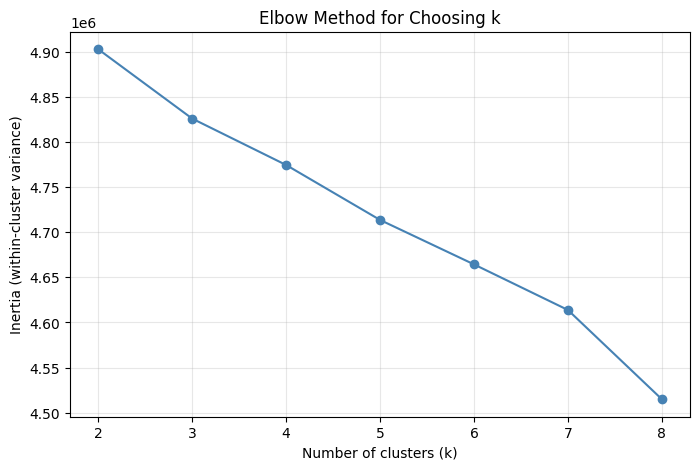

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Scale the full feature set for clustering
scaler_km = StandardScaler()
X_scaled_full = scaler_km.fit_transform(X)

# Sample for the elbow search (faster, and plenty representative)
import numpy as np
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_scaled_full), size=50000, replace=False)
X_sample = X_scaled_full[sample_idx]

# Elbow method: inertia across k values
inertias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_sample)
    inertias.append(km.inertia_)
    print(f"k={k}: inertia={km.inertia_:,.0f}")

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, 'o-', color='steelblue')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (within-cluster variance)')
plt.title('Elbow Method for Choosing k')
plt.grid(True, alpha=0.3)
plt.show()

k=2: inertia=378,607
k=3: inertia=336,753
k=4: inertia=312,826
k=5: inertia=293,935
k=6: inertia=278,770
k=7: inertia=267,102
k=8: inertia=257,303


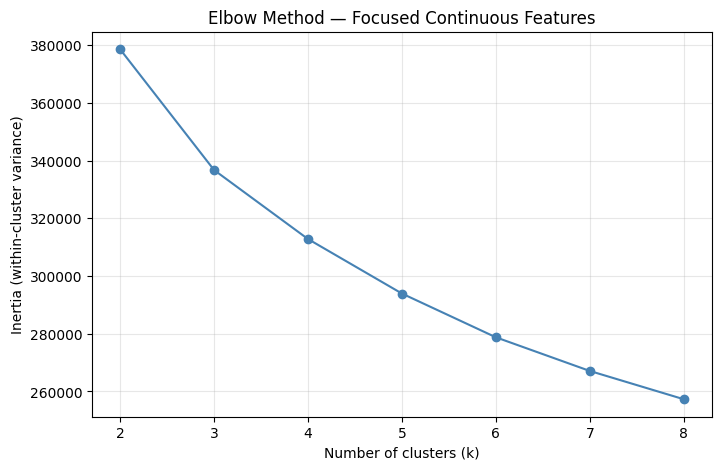

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# Focused set of continuous borrower features for clustering
cluster_features = [
    'sub_grade', 'int_rate', 'dti', 'annual_inc', 'loan_amnt',
    'credit_history_years', 'revol_util', 'total_acc', 'emp_length'
]

X_cluster = X[cluster_features].copy()

# Scale (essential for distance-based clustering)
scaler_km = StandardScaler()
X_cluster_scaled = scaler_km.fit_transform(X_cluster)

# Elbow search on a sample
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_cluster_scaled), size=50000, replace=False)
X_sample = X_cluster_scaled[sample_idx]

inertias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_sample)
    inertias.append(km.inertia_)
    print(f"k={k}: inertia={km.inertia_:,.0f}")

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, 'o-', color='steelblue')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (within-cluster variance)')
plt.title('Elbow Method — Focused Continuous Features')
plt.grid(True, alpha=0.3)
plt.show()

In [34]:
# Fit K-Means with k=4 on the focused feature set
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster_scaled)

# Profile clusters against default rate + the clustering features
profile = X[cluster_features].copy()
profile['cluster'] = cluster_labels
profile['target'] = y.values

summary = profile.groupby('cluster').agg(
    size=('target', 'size'),
    default_rate=('target', 'mean'),
    avg_subgrade=('sub_grade', 'mean'),
    avg_int_rate=('int_rate', 'mean'),
    avg_dti=('dti', 'mean'),
    avg_income=('annual_inc', 'mean'),
    avg_loan=('loan_amnt', 'mean'),
    avg_cred_hist=('credit_history_years', 'mean'),
    avg_revol_util=('revol_util', 'mean'),
).round(2)

summary['default_rate'] = (summary['default_rate'] * 100).round(1)
summary['pct_of_pop'] = (summary['size'] / len(profile) * 100).round(1)

print("=== Cluster Profiles (k=4, focused features) ===\n")
print(summary.to_string())

=== Cluster Profiles (k=4, focused features) ===

           size  default_rate  avg_subgrade  avg_int_rate  avg_dti  avg_income  avg_loan  avg_cred_hist  avg_revol_util  pct_of_pop
cluster                                                                                                                            
0        139748          15.0          8.99          0.12    14.77   144363.19  25882.84          22.78            0.56        14.8
1        236334          33.0         18.60          0.19    23.05    65007.20  16396.32          19.13            0.62        25.1
2        274482          11.0          6.06          0.10    18.95    71114.36  12120.21          23.55            0.42        29.1
3        292347          16.0          9.52          0.12    15.49    54575.23   9663.59          15.20            0.50        31.0


In [35]:
import os

# Make a results folder in your Drive
results_dir = "/content/drive/MyDrive/BA889_ResearchProposal/results"
os.makedirs(results_dir, exist_ok=True)

# 1. Model comparison summary
model_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'ROC_AUC': [0.7409, 0.7496, 0.7824],
    'Default_Recall': [0.66, 0.68, 0.72],
    'Default_Precision': [0.33, 0.34, 0.36],
})
model_results.to_csv(f"{results_dir}/model_comparison.csv", index=False)

# 2. Cluster profiles
summary.to_csv(f"{results_dir}/cluster_profiles.csv")

# 3. LR coefficients + XGBoost importances
lr_coefs.to_csv(f"{results_dir}/logreg_coefficients.csv", index=False)
xgb_imp.to_csv(f"{results_dir}/xgboost_importances.csv", index=False)

print("Saved to Drive:")
for f in os.listdir(results_dir):
    print(f"  {f}")

Saved to Drive:
  model_comparison.csv
  cluster_profiles.csv
  logreg_coefficients.csv
  xgboost_importances.csv
